# **SHAP Analysis — Model Explainability & Business ROI**

## **0. Load model, data and rebuild the same test split**

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings("ignore")

from src.data_loader import load_telco, split_features_target
from src.split_and_imbalance import split_data
from src.shap_analysis import (
    compute_shap_values,
    plot_shap_importance,
    plot_shap_dependence,
    plot_shap_waterfall_single,
    compute_roi_table,
)

IMAGES = "../images"

df = load_telco("../data/Telco-Customer-Churn.csv")
X_raw, y = split_features_target(df)

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X_raw, y)

best_model = joblib.load("../data/best_model.pkl")
print(f"Model loaded: {type(best_model.named_steps['model']).__name__}")

Model loaded: LogisticRegression


## **1. Compute SHAP values**

In [2]:
raw_model = best_model.named_steps["model"]

X_test_engineered = best_model.named_steps["features"].transform(X_test)
X_test_encoded = pd.DataFrame(
    best_model.named_steps["preprocess"].transform(X_test_engineered),
    columns=best_model.named_steps["preprocess"].get_feature_names_out(),
    index=X_test.index,
)

shap_values, explainer, X_sample = compute_shap_values(
    raw_model,
    X_test_encoded,
    sample_size=500,
)
print(f"SHAP values shape: {shap_values.shape}")

  0%|          | 0/500 [00:00<?, ?it/s]

SHAP values shape: (500, 31)


## **2. Feature Importance**

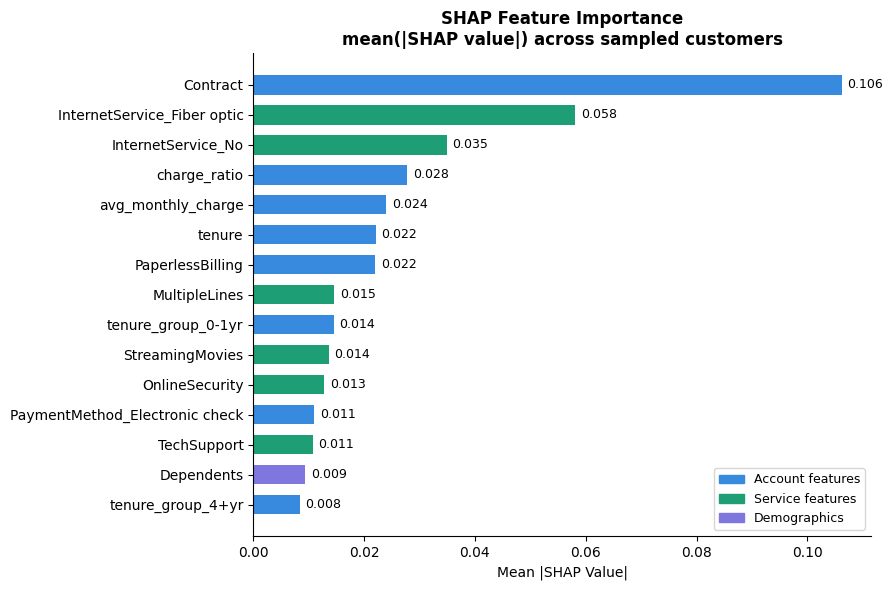

In [3]:
plot_shap_importance(
    shap_values, X_sample,
    save_path=f"{IMAGES}/shap_importance.png",
    top_n=15,
)

## **3. Dependence Plots**

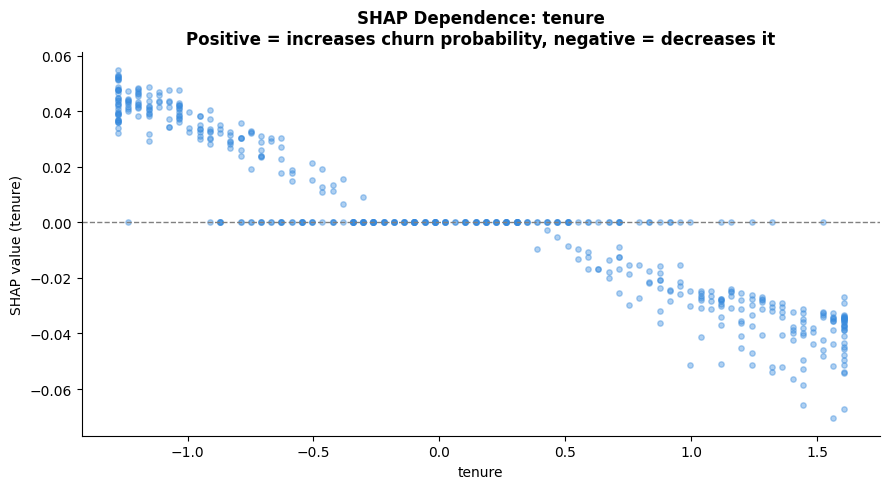

Insight: low tenure -> high positive SHAP -> strongly increases churn
Tenure > 36 months -> negative SHAP -> lower churn risk


In [4]:
plot_shap_dependence(
    shap_values, X_sample,
    feature="tenure",
    save_path=f"{IMAGES}/shap_dependence_tenure.png",
)
print("Insight: low tenure -> high positive SHAP -> strongly increases churn")
print("Tenure > 36 months -> negative SHAP -> lower churn risk")

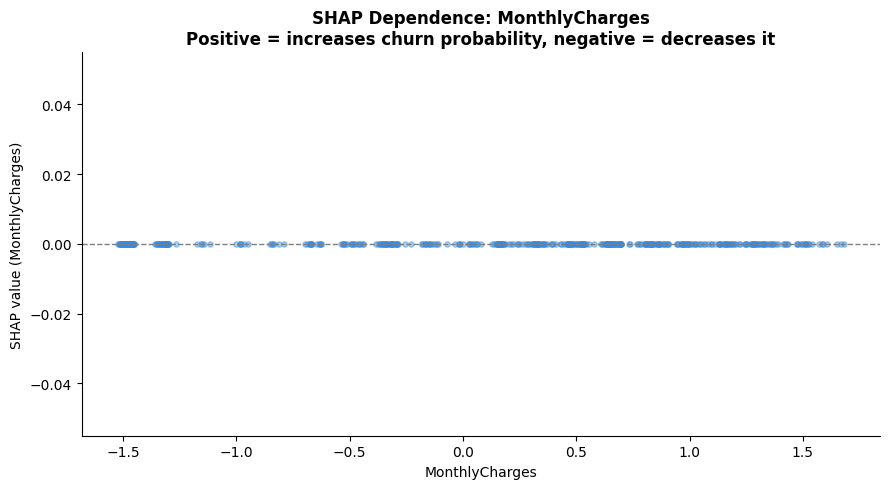

Insight: higher MonthlyCharges -> increases churn
Customers paying more but still leaving -> possible value-for-money issue


In [5]:
if "MonthlyCharges" in X_sample.columns:
    plot_shap_dependence(
        shap_values, X_sample,
        feature="MonthlyCharges",
        save_path=f"{IMAGES}/shap_dependence_monthly.png",
    )
    print("Insight: higher MonthlyCharges -> increases churn")
    print("Customers paying more but still leaving -> possible value-for-money issue")

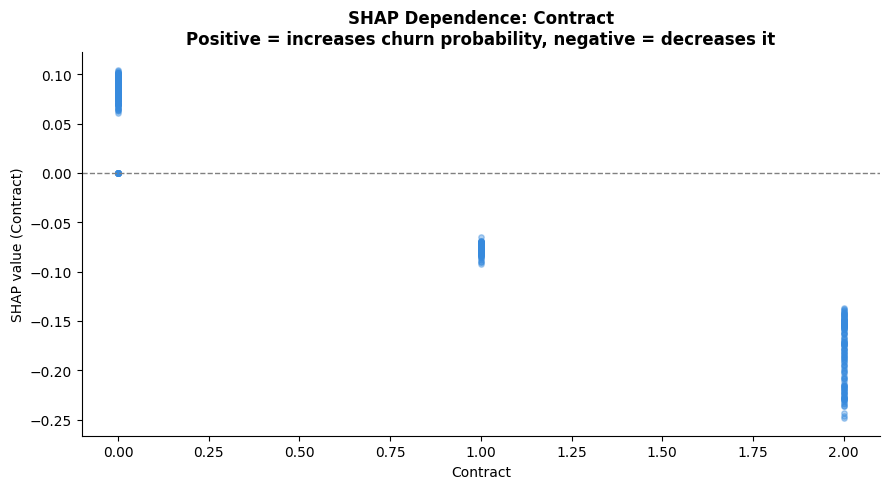

Insight: Contract=0 (Month-to-month) -> largest positive SHAP impact


In [6]:
if "Contract" in X_sample.columns:
    plot_shap_dependence(
        shap_values, X_sample,
        feature="Contract",
        save_path=f"{IMAGES}/shap_dependence_contract.png",
    )
    print("Insight: Contract=0 (Month-to-month) -> largest positive SHAP impact")

## **4. Waterfall Plot — a single test customer**

In [7]:
y_prob_all = best_model.predict_proba(X_test)[:, 1]
high_churn_idx = np.argsort(y_prob_all)[-1] 

print(f"Customer #{high_churn_idx} — churn probability: {y_prob_all[high_churn_idx]:.1%}")
cols_to_show = [c for c in ["tenure", "MonthlyCharges", "Contract", "TechSupport"] if c in X_test.columns]
print(X_test.iloc[high_churn_idx][cols_to_show] if cols_to_show else X_test.iloc[high_churn_idx, :5])

Customer #391 — churn probability: 97.6%
tenure                         1
MonthlyCharges              94.0
Contract          Month-to-month
TechSupport                   No
Name: 4800, dtype: object


  0%|          | 0/1 [00:00<?, ?it/s]

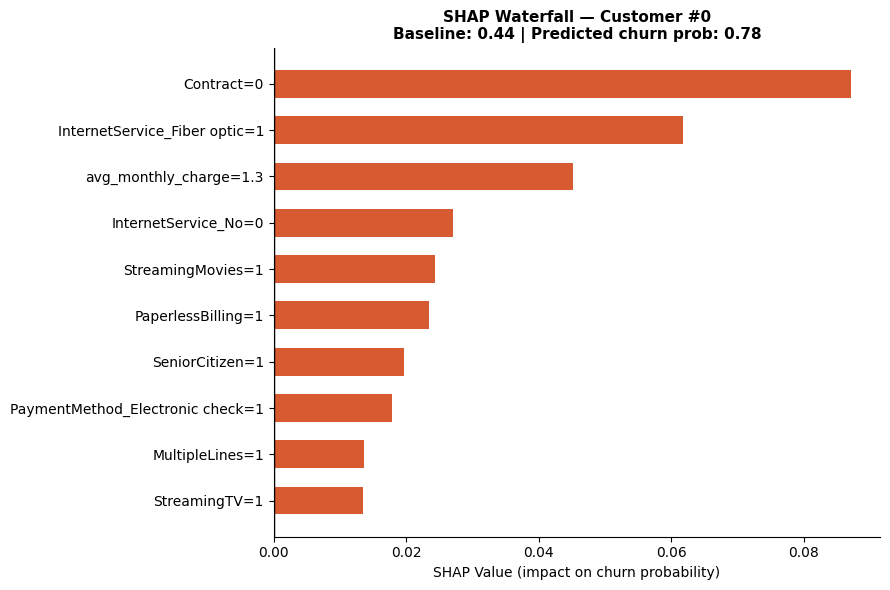

In [8]:
plot_shap_waterfall_single(
    explainer, X_sample,
    customer_idx=0,
    save_path=f"{IMAGES}/shap_waterfall.png",
)

## **5. Group Analysis — SHAP by risk segment**

=== Customer Distribution by Risk Group ===
             n_customers  avg_churn_prob  actual_churn_rate  avg_monthly
risk_group                                                              
Low Risk             616           0.117              0.052       54.114
Medium Risk          305           0.451              0.243       66.236
High Risk            488           0.770              0.549       76.678


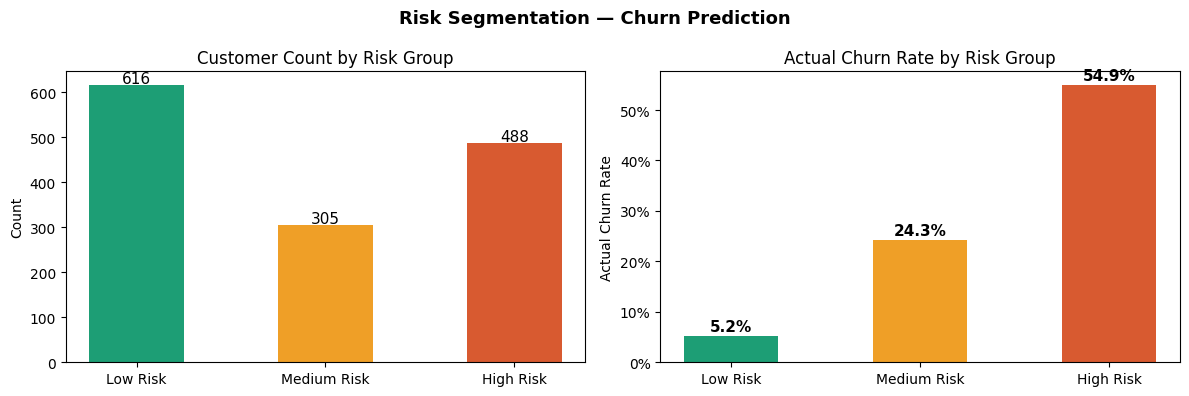

In [9]:
y_prob_test = best_model.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["churn_prob"] = y_prob_test
X_test_copy["actual_churn"] = y_test.values
X_test_copy["risk_group"] = pd.cut(
    y_prob_test,
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Low Risk", "Medium Risk", "High Risk"],
)

print("=== Customer Distribution by Risk Group ===")
risk_dist = X_test_copy.groupby("risk_group", observed=True).agg(
    n_customers=("churn_prob", "count"),
    avg_churn_prob=("churn_prob", "mean"),
    actual_churn_rate=("actual_churn", "mean"),
    avg_monthly=("MonthlyCharges", "mean") if "MonthlyCharges" in X_test_copy.columns else ("churn_prob", "mean"),
)
print(risk_dist.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
risk_counts = X_test_copy["risk_group"].value_counts().sort_index()
colors_risk = ["#1D9E75", "#EF9F27", "#D85A30"]

axes[0].bar(risk_counts.index, risk_counts.values, color=colors_risk, width=0.5)
axes[0].set_title("Customer Count by Risk Group")
axes[0].set_ylabel("Count")
for i, (_, v) in enumerate(risk_counts.items()):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=11)

actual_rates = X_test_copy.groupby("risk_group", observed=True)["actual_churn"].mean()
axes[1].bar(actual_rates.index, actual_rates.values, color=colors_risk, width=0.5)
axes[1].set_title("Actual Churn Rate by Risk Group")
axes[1].set_ylabel("Actual Churn Rate")
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
for i, (_, v) in enumerate(actual_rates.items()):
    axes[1].text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=11, fontweight="bold")

plt.suptitle("Risk Segmentation — Churn Prediction", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{IMAGES}/risk_groups.png", dpi=150, bbox_inches="tight")
plt.show()

## **6. Business ROI — was this model worth building?**


In [10]:
TUNED_THRESHOLD = 0.59 

roi_table = compute_roi_table(
    y_test, y_prob_test,
    threshold=TUNED_THRESHOLD,
    avg_monthly_revenue=65.0,      
    avg_tenure_lost=12.0,         
    retention_cost=50.0,          
    retention_success_rate=0.30,  
)
print(roi_table.to_string(index=False))

                                    Item Count    Amount
          Correctly caught churners (TP)   274  +$64,116
False alarms (FP) — retention cost spent   228  -$11,400
     Missed churners (FN) — revenue lost   100  -$78,000
                   Total retention spend   502  -$25,100
                     Total revenue saved     -  +$64,116
                Net benefit vs. no model     -   $39,016
       Revenue lost with no model at all   374 -$291,720
